# Notebook 10: Error Analysis

## Setup

In [ ]:
import os, glob, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
REPO= "Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-"
SEARCH = [f'/content/drive/MyDrive/{REPO}/bilingual results','/content/drive/MyDrive/cyberbullying_results',]
SEARCH = [p for p in SEARCH if os.path.isdir(p)]
assert SEARCH, "no results folder found"
OUT = '/content/drive/MyDrive/error_analysis'
os.makedirs(OUT, exist_ok=True)
def find(name):
    for d in SEARCH:
        p = f'{d}/{name}'
        if os.path.exists(p):
            return p
    return None

CANDIDATES = [
    f'/content/drive/MyDrive/{REPO}/Datasets/Dataset_splits',
    '/content/drive/MyDrive/dissertation_datasets/Datasets/Dataset_splits',
]
SPLITS = next((c for c in CANDIDATES if os.path.exists(f'{c}/bilingual_test.csv')), None)
assert SPLITS, "bilingual_test.csv not found - set SPLITS manually"


In [ ]:
test =pd.read_csv(f'{SPLITS}/bilingual_test.csv')
print(len(test), test.columns.tolist(), "\n")
for m in ['bilstm','distilbert', 'mbert', 'xlmr', 'ensemble']:
    p, l = find(f'{m}_bilingual_full_preds.npy'), find(f'{m}_bilingual_full_labels.npy')
    if not (p and l):
        print(f"  {m:12s} MISSING")
        continue
    aligned =np.array_equal(np.load(l), test.binary_label.values)
    print(f"{m:12s} ok  aligned={aligned}  from {os.path.basename(os.path.dirname(p))}")

13984 ['text', 'binary_label', 'language', 'source', 'media', 'clean_text'] 

  bilstm       ok  aligned=True  from bilingual results
  distilbert   ok  aligned=True  from bilingual results
  mbert        ok  aligned=True  from bilingual results
  xlmr         ok  aligned=True  from bilingual results
  ensemble     ok  aligned=True  from bilingual results


Build the prediction frame


In [ ]:
test = pd.read_csv(f'{SPLITS}/bilingual_test.csv')
if 'platform' not in test.columns:
    assert 'media' in test.columns, "neither 'platform' nor 'media' present"
    test['platform'] = test['media'].fillna('twitter')
if 'text' in test.columns:
    before =len(test)
    test= test[test['text'].astype(str).str.strip().str.len() >= 2].reset_index(drop=True)
    if before != len(test):
        print(f"dropped {before - len(test)} near-empty row(s)")

print("rows:",len(test), "| columns:", test.columns.tolist())
assert len(test)== 13984, f"expected 13,984 rows, got {len(test)}"

MODELS= {'bilstm': 'BiLSTM','distilbert': 'DistilBERT', 'mbert': 'mBERT',
          'xlmr': 'XLM-R', 'ensemble': 'Ensemble'}

df =test.copy()
loaded,provenance =[], {}
for key, label in MODELS.items():
    pf =find(f'{key}_bilingual_full_preds.npy')
    lf =find(f'{key}_bilingual_full_labels.npy')
    if pf is None or lf is None:
        print(f"  missing: {label}")
        continue
    lab=np.load(lf)
    assert np.array_equal(lab, df['binary_label'].values), f"{label}: labels misaligned"
    df[f'{key}_pred'] = np.load(pf)
    prf=find(f'{key}_bilingual_full_probs.npy')
    if prf:
        df[f'{key}_prob']= np.load(prf)[:, 1]
    loaded.append(key)
    provenance[label]= os.path.basename(os.path.dirname(pf))

print("\nloaded:", ", ".join(MODELS[k] for k in loaded))
for label, folder in provenance.items():
    print(f"  {label:12s} from {folder}")
if len(set(provenance.values())) > 1:
    print("\nNote: arrays came from more than one folder.")
print("all prediction arrays aligned to the test labels")


rows: 13984 | columns: ['text', 'binary_label', 'language', 'source', 'media', 'clean_text', 'platform']

loaded: BiLSTM, DistilBERT, mBERT, XLM-R, Ensemble
  BiLSTM       from bilingual results
  DistilBERT   from bilingual results
  mBERT        from bilingual results
  XLM-R        from bilingual results
  Ensemble     from bilingual results
all prediction arrays aligned to the test labels


Where the models fail


In [ ]:
PRIMARY ='ensemble' if 'ensemble' in loaded else 'xlmr'
print("primary model:", MODELS[PRIMARY])
for k in loaded:
    df[f'{k}_correct']=(df[f'{k}_pred'] == df['binary_label']).astype(int)

transformers = [k for k in ['distilbert', 'mbert', 'xlmr'] if k in loaded]
df['n_transformers_correct']= df[[f'{k}_correct' for k in transformers]].sum(axis=1)
rows = []
for k in loaded:
    e =(df[f'{k}_correct']== 0)
    rows.append({'Model': MODELS[k],
                 'Errors': int(e.sum()),'Error rate': f"{100*e.mean():.2f}%",
                 'English': int((e & (df.language == 'en')).sum()), 'Spanish': int((e & (df.language == 'es')).sum())})
print(pd.DataFrame(rows).to_string(index=False))

errors=df[df[f'{PRIMARY}_correct'] == 0].copy()
errors['error_type'] = np.where(errors[f'{PRIMARY}_pred'] == 1, 'False Positive', 'False Negative')
print("\nerror type by language")
print(errors.groupby(['language', 'error_type']).size().unstack(fill_value=0).to_string())

primary model: Ensemble
     Model  Errors Error rate  English  Spanish
    BiLSTM    1588     11.36%      963      625
DistilBERT    1275      9.12%      727      548
     mBERT    1254      8.97%      724      530
     XLM-R    1146      8.20%      692      454
  Ensemble    1141      8.16%      680      461

error type by language
error_type  False Negative  False Positive
language                                  
en                     305             375
es                     202             259


Error rates by source and platform


In [ ]:
for col in ['source', 'platform']:
    if col not in df.columns:
        print(f"'{col}' not in the test file; skipping"); continue
    t =(df.groupby(col).agg(n=('binary_label', 'size'),
                errors=(f'{PRIMARY}_correct', lambda s: int((s == 0).sum()))).assign(error_rate=lambda d: (100*d.errors/d.n).round(2))
           .sort_values('error_rate', ascending=False))

  print(f"\nerror rate by {col}")
    print(t.to_string())
    t.to_csv(f'{OUT}/error_rate_by_{col}.csv')

if {'source', 'platform'}<=set(df.columns):
    off = df[df['source']== 'OffendES']
    if len(off):
        t =(off.groupby('platform')
               .agg(n=('binary_label', 'size'),
                    errors=(f'{PRIMARY}_correct', lambda s: int((s == 0).sum())))
               .assign(error_rate=lambda d: (100*d.errors/d.n).round(2)))
        print("\nOffendES only, by platform")
        print(t.to_string())
        t.to_csv(f'{OUT}/error_rate_offendes_by_platform.csv')
if {'source', 'platform'}<= set(df.columns):
    ct =pd.crosstab(df['source'], df['platform'])
    print("\nsource x platform")
    print(ct.to_string())
    ct.to_csv(f'{OUT}/source_by_platform.csv')

    multi =(ct > 0).sum(axis=1)
    print(f"\nsources spanning more than one platform: " f"{', '.join(multi[multi > 1].index) or 'none'}")
    print("all remaining sources are Twitter-only")



error rate by source
                  n  errors  error_rate
source                                 
Colombian       398      82       20.60
OffendES       2668     349       13.08
English_CB     6092     661       10.85
ES_homomex       40       3        7.50
ES_chileno      102       7        6.86
ES_hascosva      64       2        3.12
ES_haternet     258       8        3.10
ES_hateval      397       9        2.27
TweetEval      3751      19        0.51
ES_misocorpus   214       1        0.47

error rate by platform
               n  errors  error_rate
platform                            
youtube     1972     264       13.39
instagram    523      64       12.24
twitter    11489     813        7.08

OffendES only, by platform
              n  errors  error_rate
platform                           
instagram   523      64       12.24
twitter     173      21       12.14
youtube    1972     264       13.39

source x platform
platform       instagram  twitter  youtube
source             

Inter-model disagreement


transformers correct, out of three
  0:    664  ( 4.75%)
  1:    502  ( 3.59%)
  2:    679  ( 4.86%)
  3:  12139  (86.81%)

all three wrong: 664 rows (4.75%), 419 English and 245 Spanish


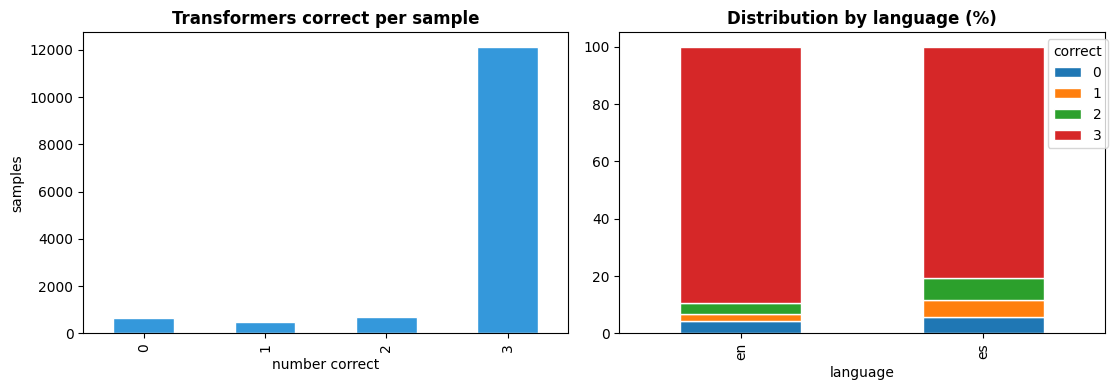

In [ ]:
if len(transformers)== 3:
    dist = df['n_transformers_correct'].value_counts().sort_index()
    print("transformers correct, out of three")
    for k,v in dist.items():
        print(f"  {k}: {v:6d}  ({100*v/len(df):5.2f}%)")

    hard =df[df['n_transformers_correct'] == 0]
    print(f"\nall three wrong: {len(hard)} rows "
          f"({100*len(hard)/len(df):.2f}%), "
          f"{(hard.language=='en').sum()} English and {(hard.language=='es').sum()} Spanish")

    fig,axes = plt.subplots(1, 2, figsize=(12, 4))
    dist.plot(kind='bar',ax=axes[0], color='#3498db', edgecolor='white')
    axes[0].set_title('Transformers correct per sample', fontweight='bold')
    axes[0].set_xlabel('number correct');axes[0].set_ylabel('samples')
    ct = pd.crosstab(df.language, df['n_transformers_correct'], normalize='index')*100
    ct.plot(kind='bar',stacked=True, ax=axes[1], edgecolor='white')
    axes[1].set_title('Distribution by language (%)', fontweight='bold')
    axes[1].legend(title='correct', bbox_to_anchor=(1.02, 1))
    plt.tight_layout();plt.savefig(f'{OUT}/model_agreement.png', dpi=300, bbox_inches='tight')
    plt.show()

Sample for annotation

Thirty per language, stratified by error type so false positives and false
negatives are both represented in proportion.

In [ ]:
N_PER_LANG= 30
np.random.seed(42)
def stratified_errors(sub, n):
    parts =[]
    for et,g in sub.groupby('error_type'):
        k=max(1, round(n * len(g) / len(sub)))
        parts.append(g.sample(min(k, len(g)), random_state=42))
    out =pd.concat(parts)
    return out.sample(min(n, len(out)),random_state=42).sort_values('error_type')

samples={}
for lang, name in [('en', 'english'), ('es', 'spanish')]:
    sub=errors[errors.language == lang]
    s =stratified_errors(sub, N_PER_LANG)
    s =s.assign(error_category='', notes='')
    samples[name] = s
    print(f"{name}: {len(s)} sampled from {len(sub)} errors "
          f"({dict(s.error_type.value_counts())})")

cols=([c for c in ['text', 'language', 'binary_label','source', 'platform'] if c in df.columns]
        + [f'{k}_pred' for k in loaded] + ['error_type','error_category', 'notes'])

for name,s in samples.items():
    s[cols].to_csv(f'{OUT}/error_analysis_{name}.csv',index=False)
    print(f"written: {OUT}/error_analysis_{name}.csv")

english: 30 sampled from 680 errors ({'False Positive': np.int64(17), 'False Negative': np.int64(13)})
spanish: 30 sampled from 461 errors ({'False Positive': np.int64(17), 'False Negative': np.int64(13)})
written: /content/drive/MyDrive/error_analysis/error_analysis_english.csv
written: /content/drive/MyDrive/error_analysis/error_analysis_spanish.csv


**Annotation scheme**

Fill the error_category column with one of:


**label_noise**= The ground-truth label appears wrong; the model was right

**implicit**= Abuse is implied rather than stated; no explicit trigger

**lexical_trigger**= A profane or charged term appears in non-abusive use

**cultural**  = Regional slang, idiom or reference the model missed

**code_switch**= English and Spanish mixed within the post

**ambiguous** = Genuinely unclear without conversational context

**other**= Does not fit the above

Aggregating the annotations after annotating the CSVs


language         English  Spanish  Total
error_category                          
other                 11        7     18
ambiguous              7        7     14
lexical trigger        6        7     13
implicit               2        5      7
label_noise            3        3      6
cultural               1        1      2

as a percentage within each language
language         English  Spanish
error_category                   
ambiguous           23.3     23.3
cultural             3.3      3.3
implicit             6.7     16.7
label_noise         10.0     10.0
lexical trigger     20.0     23.3
other               36.7     23.3


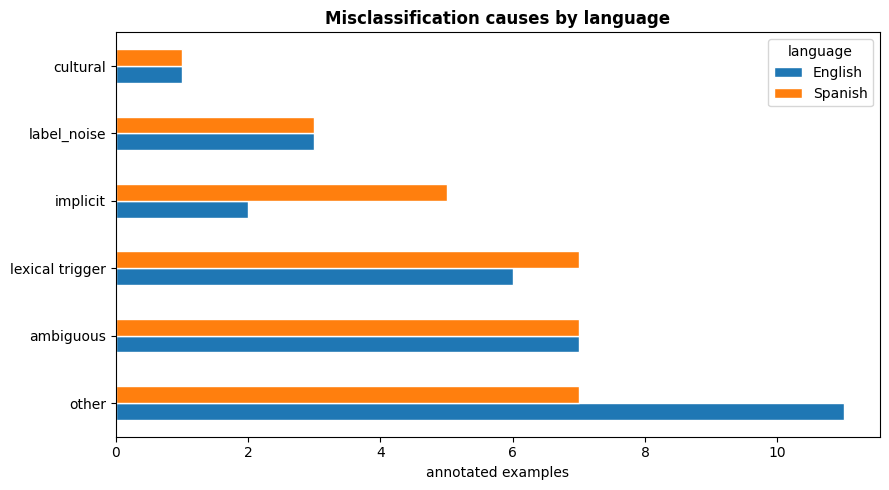


cross-tabulated with error type
error_type       False Negative  False Positive
error_category                                 
ambiguous                     6               8
cultural                      0               2
implicit                      4               3
label_noise                   6               0
lexical trigger               6               7
other                         4              14


In [ ]:
try:
    en= pd.read_csv(f'{OUT}/error_analysis_english.csv')
    es=pd.read_csv(f'{OUT}/error_analysis_spanish.csv')
except FileNotFoundError:
    raise SystemExit("Annotation files not found; complete Part 5 first")

en['language'], es['language']= 'English','Spanish'
both=pd.concat([en, es])
both['error_category'] =both['error_category'].fillna('unannotated').str.strip().str.lower()

tab = pd.crosstab(both['error_category'],both['language'])
tab['Total'] =tab.sum(axis=1)
tab = tab.sort_values('Total',ascending=False)
print(tab.to_string())
tab.to_csv(f'{OUT}/error_category_distribution.csv')

pct=pd.crosstab(both['error_category'], both['language'], normalize='columns') * 100
print("\nas a percentage within each language")
print(pct.round(1).to_string())

ax = tab.drop(columns='Total').plot(kind='barh', figsize=(9, 5),edgecolor='white')
ax.set_title('Misclassification causes by language',fontsize=12, fontweight='bold')
ax.set_xlabel('annotated examples');ax.set_ylabel('')
plt.tight_layout(); plt.savefig(f'{OUT}/error_categories.png', dpi=300, bbox_inches='tight')
plt.show()
print("\ncross-tabulated with error type")
print(pd.crosstab(both['error_category'], both['error_type']).to_string())

#Label quality audit

The annotation above recorded six `label_noise` cases in 60 examples, but that
category competed with `ambiguous` and `other` for the same instances, so it
under-counts. This part measures the rate directly, with TweetEval as a control:
if English_CB comes back high and TweetEval near zero, the performance ceiling
tracks corpus quality rather than language or architecture.


In [ ]:
if 'source' in df.columns:
    cb = df[(df['source'] == 'English_CB') & (df['binary_label'] == 1)]
    ctrl = df[(df['source'] == 'TweetEval') & (df['binary_label'] == 1)]
    print(f"English_CB abusive rows: {len(cb)}   TweetEval abusive rows: {len(ctrl)}")

    audit = pd.concat([
        cb.sample(min(100, len(cb)), random_state=42).assign(audit_source='English_CB'),
        ctrl.sample(min(50, len(ctrl)), random_state=42).assign(audit_source='TweetEval'),
    ])[['text', 'binary_label', 'platform', 'audit_source']]

    audit = audit.sample(frac=1, random_state=42).reset_index(drop=True)
    audit = audit.assign(is_abusive='', note='')
    audit.to_csv(f'{OUT}/label_audit.csv', index=False)

    print(f"\nwritten: {OUT}/label_audit.csv  ({len(audit)} rows)")

English_CB abusive rows: 4917   TweetEval abusive rows: 0

written: /content/drive/MyDrive/error_analysis/label_audit.csv  (100 rows)

 



In [ ]:
try:
    a =pd.read_csv(f'{OUT}/label_audit.csv')
except FileNotFoundError:
    raise SystemExit("Run the sampling cell first")

a['is_abusive'] = a['is_abusive'].fillna('').astype(str).str.strip().str.lower()
if (a['is_abusive']== '').all():
    print("label_audit.csv is not annotated yet.")
else:
    try:
        from statsmodels.stats.proportion import proportion_confint
    except ImportError:
        proportion_confint = None

    for src, g in a.groupby('audit_source'):
        done = g[g['is_abusive'].isin(['y', 'n', 'unclear'])]
        if not len(done):
            continue
        k, n = (done['is_abusive'] == 'n').sum(), len(done)
        unclear = (done['is_abusive'] == 'unclear').sum()
        line = f"  {src:12s} mislabelled {k}/{n} = {100*k/n:.1f}%"
        if proportion_confint is not None:
            lo, hi = proportion_confint(k, n, method='wilson')
            line += f"  (95% CI {100*lo:.1f}-{100*hi:.1f})"
        line += f"   unclear {unclear}"
        print(line)

  English_CB   mislabelled 43/100 = 43.0%  (95% CI 33.7-52.8)   unclear 0





In [ ]:
CTRL_FILE = f'{OUT}/label_audit_control.csv'
if os.path.exists(CTRL_FILE) and \
   pd.read_csv(CTRL_FILE)['is_abusive'].astype(str).str.strip().ne('').any():
    print("control audit already annotated - not regenerating")
else:
    cb_neg = df[(df['source'] == 'English_CB') & (df['binary_label'] == 0)]
    print(f"English_CB non-abusive rows available: {len(cb_neg)}")

    ctrl = (cb_neg.sample(min(50, len(cb_neg)), random_state=42)
                  .assign(audit_source='English_CB_nonabusive')
                  [['text', 'binary_label', 'platform', 'audit_source']].reset_index(drop=True)
                  .assign(is_abusive='', note=''))
    ctrl.to_csv(CTRL_FILE, index=False)

    print(f"written:{CTRL_FILE} ({len(ctrl)} rows)")

English_CB non-abusive rows available: 1175
written: /content/drive/MyDrive/error_analysis/label_audit_control.csv (50 rows)






In [ ]:
def score(path, label_value):
    if not os.path.exists(path):
        return None
    a = pd.read_csv(path)
    a['is_abusive'] = a['is_abusive'].fillna('').astype(str).str.strip().str.lower()
    done = a[a['is_abusive'].isin(['y', 'n', 'unclear'])]
    if not len(done):
        return None
    wrong ='n' if label_value == 1 else 'y'
    k, n= (done['is_abusive'] == wrong).sum(), len(done)
    return k, n, (done['is_abusive'] == 'unclear').sum()

try:
    from statsmodels.stats.proportion import proportion_confint
except ImportError:
    proportion_confint = None

rows =[]
for name, path, lv in [
    ('English_CB abusive',f'{OUT}/label_audit.csv',1),
    ('English_CB non-abusive',f'{OUT}/label_audit_control.csv', 0),
]:
    r = score(path,lv)
    if r is None:
        print(f"{name:26s} not annotated yet")
        continue
    k, n, unclear = r
    lo, hi = proportion_confint(k, n, method='wilson') if proportion_confint else (None, None)
    ci= f"95% CI {100*lo:.1f}-{100*hi:.1f}" if lo is not None else ""
    print(f"{name:26s} mislabelled {k}/{n} = {100*k/n:5.1f}%{ci}   unclear {unclear}")
    rows.append({'sample': name, 'mislabelled': k, 'n': n,'rate_pct': round(100*k/n, 1), 'unclear': unclear})

if len(rows) == 2:
    pd.DataFrame(rows).to_csv(f'{OUT}/label_audit_summary.csv', index=False)
    gap=rows[0]['rate_pct'] - rows[1]['rate_pct']
    print(f"\ndirectional gap: {gap:+.1f} pp")

  English_CB abusive         mislabelled 43/100 =  43.0%  95% CI 33.7-52.8   unclear 0
  English_CB non-abusive     mislabelled 10/50 =  20.0%  95% CI 11.2-33.0   unclear 0

directional gap: +23.0 pp



